conda create -n ai-econ-legacy python=3.7.16 -y
conda activate ai-econ-legacy

pip install "numpy==1.16.4"
pip install "tensorflow==1.14.0"
pip install "gym<0.23"
pip install "ray[rllib]==1.13.0"
pip install jupyter ipykernel tensorboard
python -m ipykernel install --user --name ai-econ-legacy --display-name "Python (ai-econ-legacy)"

In [4]:
import sys
import ray
import numpy as np
import tensorflow as tf
import gym


import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd

import random

c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\s

In [5]:
sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

from utils import plotting

import ray
from ray.rllib.agents.ppo import PPOTrainer

In [6]:
from rllib.env_wrapper import RLlibEnvWrapper


# training sim

In [13]:
import simulation as exp

import ray
ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False)

settings = exp.ExperimentSettings(
    phase1_iters = 50,
    phase2_iters = 125,
    phase3a_iters = 50,
    phase3b_iters = 125,
    save_results=False,
    travel_enabled_phase3a=False,
    travel_enabled_phase3b=False,
    experiment_extra_tag = "Original_with_travel",
)

results = exp.run_experiment(settings)

2026-04-15 09:36:08,880	INFO resource_spec.py:212 -- Starting Ray with 2.34 GiB memory available for workers and up to 1.17 GiB for objects. You can adjust these settings with ray.init(memory=<bytes>, object_store_memory=<bytes>).


2026-04-15 09:36:09,493	INFO services.py:1165 -- View the Ray dashboard at localhost:8265
2026-04-15 09:36:14,855	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-15 09:36:14,859	INFO trainer.py:585 -- Tip: set framework=tfe or the --eager flag to enable TensorFlow eager execution
2026-04-15 09:36:14,859	INFO trainer.py:612 -- Current log_level is WARN. For more information, set 'log_level': 'INFO' / 'DEBUG' or use the -v and -vv flags.


Skipping saving results (save_results=False)
Instructions for updating:
Use `tf.random.categorical` instead.
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


2026-04-15 09:36:31,067	INFO trainable.py:181 -- _setup took 16.211 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


Instructions for updating:
Prefer Variable.assign which has equivalent behavior in 2.X.
[PHASE 1] Iter=0000/50 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 47.10714285714327
[PHASE 1] Iter=0025/50 reward=564.288058697877
   p_top reward: 152.45000000000113, p_bottom reward: 118.75000000000114
   social welfare (coin_eq_times_prod): 203.8571428571431
[PHASE 1] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_09-36-14xe4c5zwk\checkpoint_50\checkpoint-50  (5.8 min)


...

[PHASE 2] Iter=0000/125 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 282.79154017857155
[PHASE 2] Iter=0025/125 reward=1119.1796549214964
   p_top reward: 300.18471354166707, p_bottom reward: 272.2478085937504
   social welfare (coin_eq_times_prod): 275.4935267857143
[PHASE 2] Iter=0050/125 reward=1132.9645599895125
   p_top reward: 297.4914166666671, p_bottom reward: 278.2989804687504
   social welfare (coin_eq_times_prod): 195.429603794643
[PHASE 2] Iter=0075/125 reward=1122.201114920784
   p_top reward: 295.072731336806, p_bottom reward: 277.97732074652816
   social welfare (coin_eq_times_prod): 251.59899553571438
[PHASE 2] Iter=0100/125 reward=1124.1428654225288
   p_top reward: 295.14777083333377, p_bottom reward: 278.7717073567712
   social welfare (coin_eq_times_prod): 215.69900669642868
[PHASE 2] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_09-42-34lra9mwk_\checkpoint_125\checkpoint-125  (16.1 min)


2026-04-15 09:59:33,012	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-15 09:59:55,293	INFO trainable.py:181 -- _setup took 22.280 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


[PHASE 3A] Iter=0000/50 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 250.59198660714293
[PHASE 3A] Iter=0025/50 reward=1096.3674396540073
   p_top reward: 282.11763932291706, p_bottom reward: 269.71934895833385
   social welfare (coin_eq_times_prod): 213.41843750000018
[PHASE 3A] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_09-59-32zl8qyfui\checkpoint_50\checkpoint-50  (7.0 min)


2026-04-15 10:07:06,352	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-15 10:07:52,261	INFO trainable.py:181 -- _setup took 45.908 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


[PHASE 3B] Iter=0000/125 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 226.81107142857158
[PHASE 3B] Iter=0025/125 reward=1081.3148542094734
   p_top reward: 258.92739062500044, p_bottom reward: 280.00002473958375
   social welfare (coin_eq_times_prod): 247.2352232142858
[PHASE 3B] Iter=0050/125 reward=1107.8214245025345
   p_top reward: 272.11654101562533, p_bottom reward: 279.6355781250004
   social welfare (coin_eq_times_prod): 220.60454520089291
[PHASE 3B] Iter=0075/125 reward=1079.6764054337407
   p_top reward: 258.56947309027817, p_bottom reward: 275.3023823784726
   social welfare (coin_eq_times_prod): 289.3731026785715
[PHASE 3B] Iter=0100/125 reward=1113.0212059787377
   p_top reward: 264.5558694661462, p_bottom reward: 284.3821637369796
   social welfare (coin_eq_times_prod): 254.78302455357152
[PHASE 3B] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_10-07-064_255_yq\checkpoint_125\checkpoint-125  (

In [14]:
results["summary"]
results["metrics_df"]

dense_logs = results["dense_logs"]

In [15]:
phase_envs = exp.build_all_phase_env_configs(settings)

env_config_dict_phase3b = phase_envs["phase3b"]

env_obj_phase1 = results["envs"]["phase1"]
env_obj_phase3b = results["envs"]["phase3b"]

trainer_phase3b = results["trainers"]["phase3b"]

In [16]:
def summarize_travel_events(dense_log):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]

    counts = {}
    for e in events:
        aid = e["agent"]
        counts[aid] = counts.get(aid, 0) + 1

    print("Successful travels per agent:")
    for aid in sorted(counts):
        print(f"Agent {aid}: {counts[aid]}")

    print("Total successful travels:", sum(counts.values()))

summarize_travel_events(dense_logs[0])

def print_travel_events(dense_log, max_events=30):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]
    print(f"Showing first {min(len(events), max_events)} travel events:")
    for e in events[:max_events]:
        print(e)

print_travel_events(dense_logs[0], max_events=50)

def check_travel_cooldowns(dense_log, agent_id=0):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    ts = [e["t"] for e in dense_log["CrossWaterTravel"] if e["agent"] == agent_id]
    print("Travel times:", ts)

    if len(ts) > 1:
        gaps = [ts[i+1] - ts[i] for i in range(len(ts)-1)]
        print("Gaps:", gaps)

check_travel_cooldowns(dense_logs[0], agent_id=0)

Successful travels per agent:
Total successful travels: 0
Showing first 0 travel events:
Travel times: []


In [20]:
def build_counts_by_agent(dense_log):
    counts = {}
    for b in dense_log.get("Build", []):
        events = b.get("builds", []) if isinstance(b, dict) else b
        for ev in events:
            builder = str(ev.get("builder"))
            counts[builder] = counts.get(builder, 0) + 1
    print("build counts by agent:", counts)
    print("total builds:", sum(counts.values()))
    return counts

In [21]:
build_counts_by_agent(dense_logs[0])

build counts by agent: {'4': 26, '0': 24, '5': 34, '6': 4, '1': 40, '7': 1, '3': 9, '2': 30}
total builds: 168


{'4': 26, '0': 24, '5': 34, '6': 4, '1': 40, '7': 1, '3': 9, '2': 30}

In [ ]:
obs = env_obj_phase3b.reset()

agent 0 loc: [0, 0]
agent 4 loc: [26, 0]
obs[0]: {'world-map': array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.],
        [0., 0., 

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :   3.50 (n= 10) |   3.36 (n= 36) |   3.83 (n= 59) |   3.69 (n= 55) |   3.36 (n= 33) |   3.69 (n= 26) |   3.33 (n= 21) |   3.58 (n= 24)
Cost (Stone)   :   4.32 (n= 28) |   4.31 (n= 29) |   4.03 (n= 38) |   3.95 (n= 22) |   4.02 (n= 57) |   3.52 (n= 31) |   4.25 (n= 36) |   4.50 (n= 20)

Income (Wood)  :   3.88 (n= 52) |   3.57 (n= 35) |   3.75 (n= 16) |   3.89 (n= 18) |   3.59 (n= 17) |   3.44 (n= 62) |   3.68 (n= 19) |   3.27 (n= 45)
Income (Stone) :   4.09 (n= 47) |   4.09 (n= 44) |   3.86 (n= 36) |   3.48 (n= 23) |   4.72 (n= 29) |   3.74 (n= 27) |   4.29 (n= 31) |   4.38 (n= 24)
Income (Build) :  11.00 (n= 24) |  11.00 (n= 26) |  13.00 (n= 40) |  13.00 (n= 34) |  16.00 (n= 30) |  16.00 (n=  4) |  22.00 (n=  9) |  22.00 (n=  1)


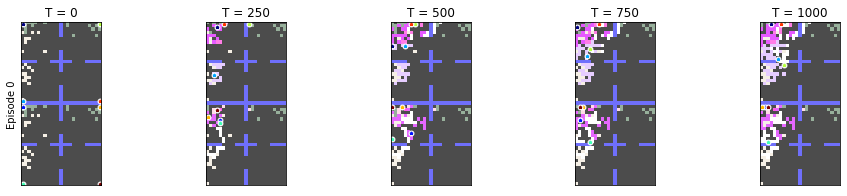

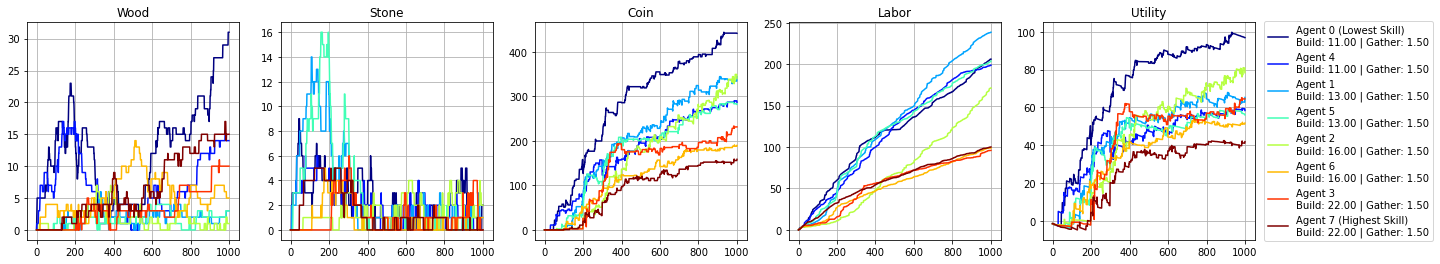

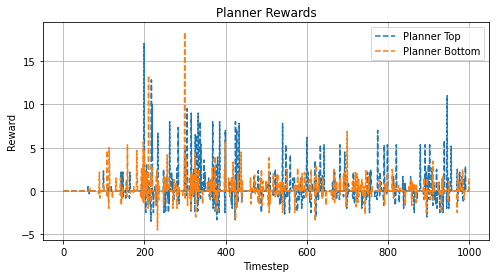

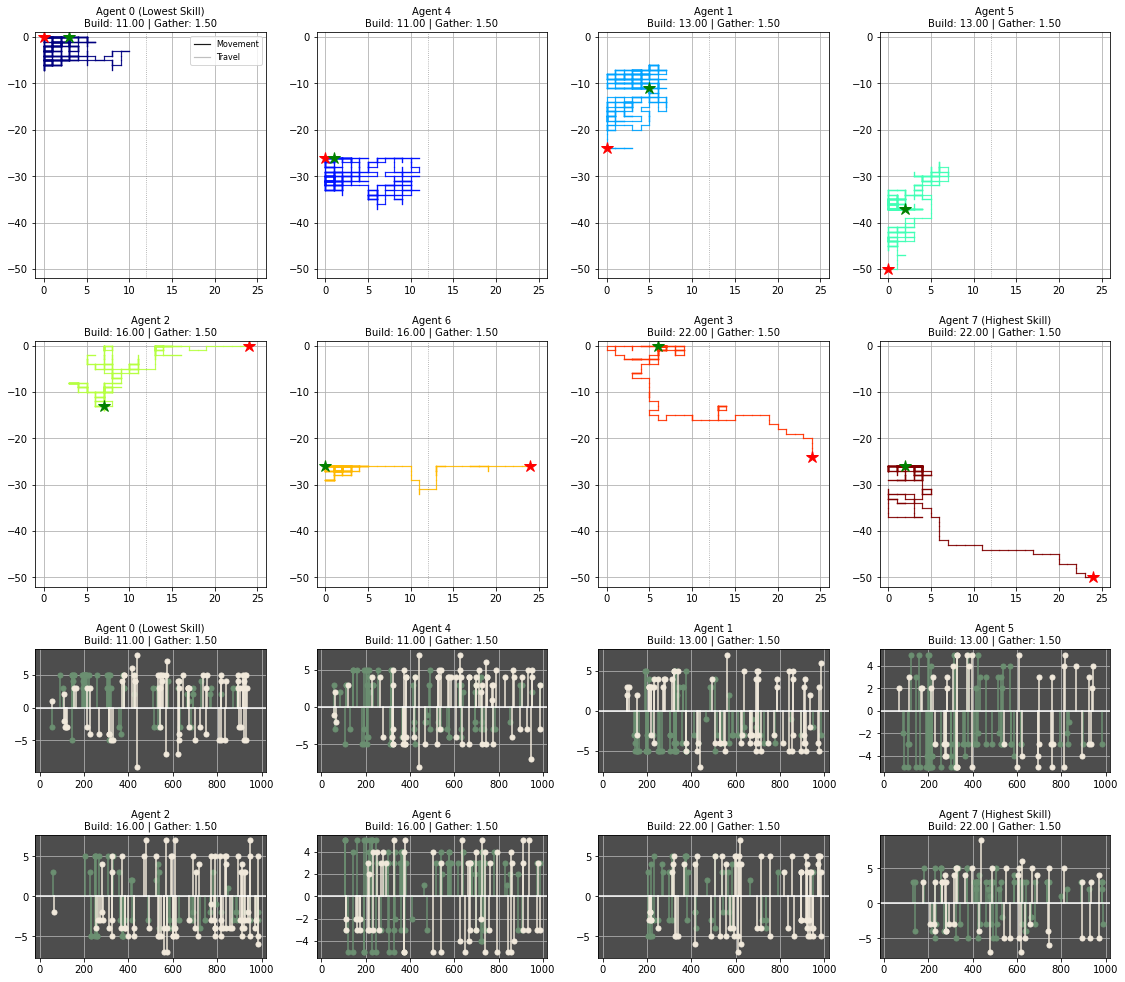

In [39]:
(fig0, fig1, fig1_planner, fig2), incomes, endows, c_trades, all_builds = plotting.breakdown_all_agents(
    dense_logs[0],
    n_cols=4,
)

,tax_period,stone_trades,stone_inventory_total,stone_escrow_total,stone_on_map,builds
0,0,8,13.91,10.49,30.0,20.0
1,1,23,25.98,21.70,19.5,21.0
2,2,25,30.59,24.24,17.5,29.0
3,3,13,32.25,29.36,18.0,21.0
4,4,21,26.93,31.97,28.5,9.0
5,5,16,31.52,34.03,34.5,14.0
6,6,16,38.01,32.49,30.0,7.0
7,7,16,40.43,36.92,31.0,6.0
8,8,9,41.13,36.79,33.5,8.0
9,9,26,40.83,31.31,36.0,13.0


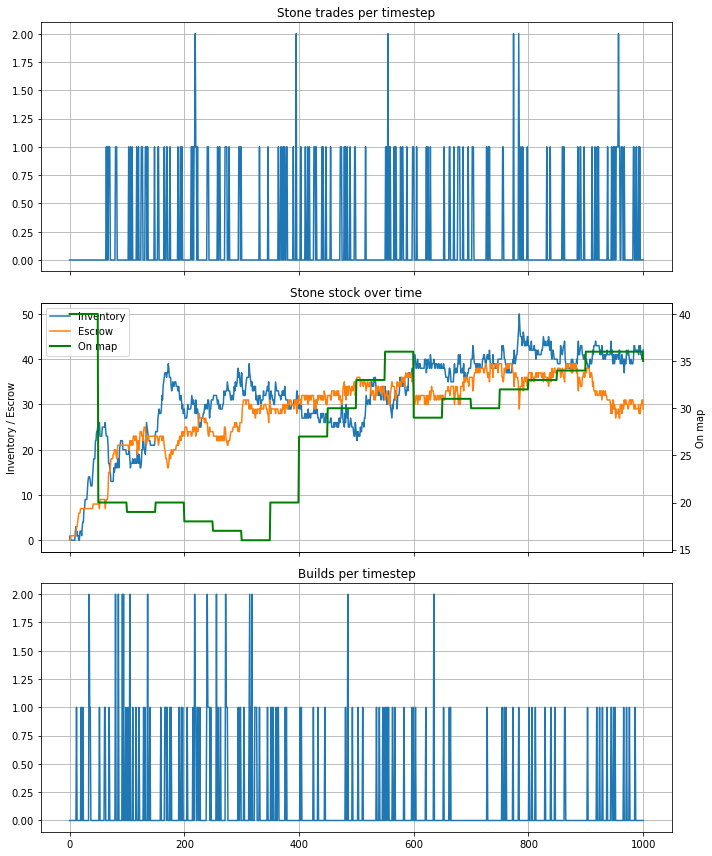

In [ ]:
df_stone_t, df_stone_p, fig = plotting.diagnose_resource_market(dense_logs[0], resource="Stone", period=100)
df_stone_p

,tax_period,wood_trades,wood_inventory_total,wood_escrow_total,wood_on_map,builds
0,0,6,6.08,11.27,34.0,20.0
1,1,31,9.88,10.68,27.0,21.0
2,2,43,7.61,9.15,28.5,29.0
3,3,46,3.53,1.74,29.0,21.0
4,4,26,3.37,4.36,31.5,9.0
5,5,59,3.06,6.32,31.5,14.0
6,6,18,0.82,1.55,31.0,7.0
7,7,62,1.63,1.99,35.0,6.0
8,8,42,1.33,1.27,33.0,8.0
9,9,52,2.52,7.05,32.5,13.0


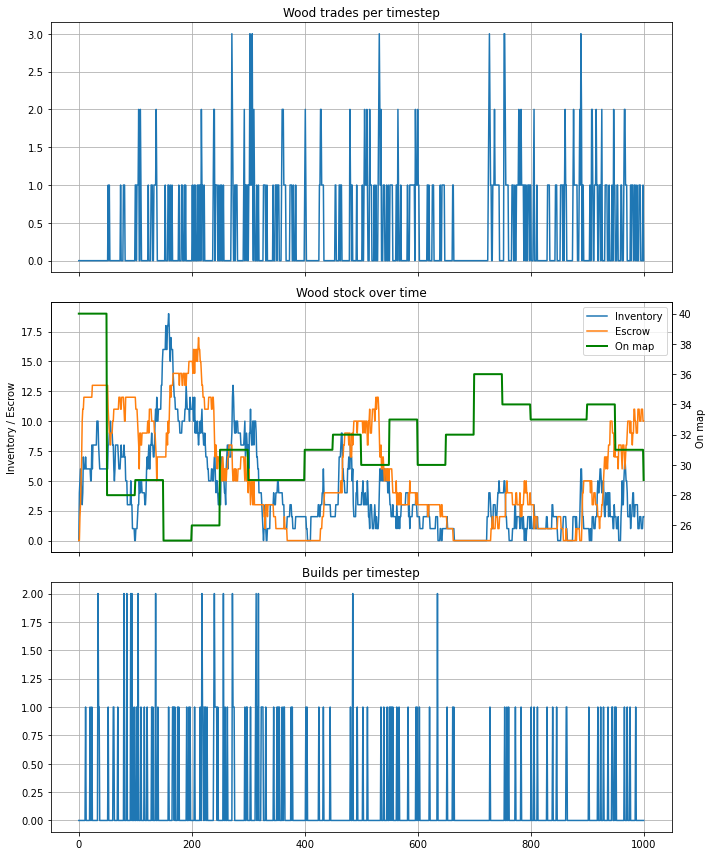

In [ ]:
df_wood_t, df_wood_p, fig = plotting.diagnose_resource_market(dense_logs[1], resource="Wood", period=100)
df_wood_p

In [ ]:
df_income, df_tax_counts = plotting.tax_day_income_report(dense_logs[0], period=100)
df_income.head(20)
df_tax_counts

,tax_day_number,region,tax_bracket,n_agents
0,1,bottom,"[0.000, 9.700)",1
1,1,top,"[0.000, 9.700)",5
2,1,top,"[39.475, 84.200)",2
3,2,bottom,"[0.000, 9.700)",1
4,2,top,"[0.000, 9.700)",1
5,2,top,"[39.475, 84.200)",2
6,2,top,"[84.200, 160.725)",1
7,2,top,"[9.700, 39.475)",3
8,3,bottom,"[39.475, 84.200)",1
9,3,top,"[39.475, 84.200)",3


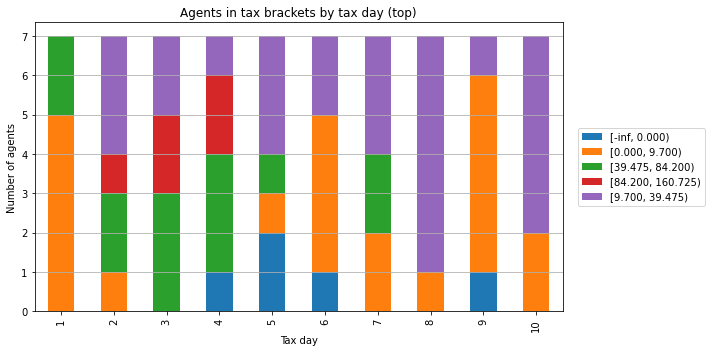

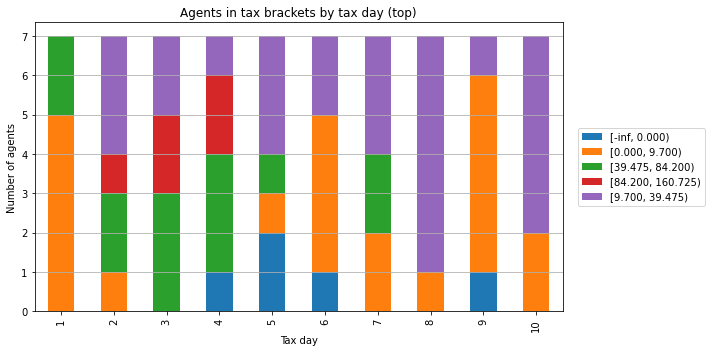

In [44]:
import matplotlib.pyplot as plt

def plot_tax_group_counts(df_counts, region=None):
    df = df_counts.copy()
    if region is not None:
        df = df[df["region"] == region]

    pivot = df.pivot_table(
        index="tax_day_number",
        columns="tax_bracket",
        values="n_agents",
        aggfunc="sum",
        fill_value=0,
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax)

    title = "Agents in tax brackets by tax day"
    if region is not None:
        title += f" ({region})"
    ax.set_title(title)
    ax.set_xlabel("Tax day")
    ax.set_ylabel("Number of agents")
    ax.grid(True, axis="y")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    return fig, pivot

fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")
fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")

In [ ]:
df_inv = plotting.inventory_table_by_tax_period(dense_logs[0], period=100, include_escrow=True)
df_inv

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,top,57.000000,10.0,0.0,1.0,4.0,3.0,58.000000,14.0,3.0
1,1,99,1,top,0.000000,0.0,6.0,0.0,0.0,5.0,0.000000,0.0,11.0
2,1,99,2,bottom,0.000000,0.0,0.0,1.0,0.0,1.0,1.000000,0.0,1.0
3,1,99,3,top,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,1,99,4,top,43.000000,5.0,0.0,2.0,3.0,5.0,45.000000,8.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,top,226.400625,5.0,0.0,5.0,5.0,0.0,231.400625,10.0,0.0
76,10,999,4,top,289.221328,9.0,0.0,1.0,5.0,0.0,290.221328,14.0,0.0
77,10,999,5,top,275.586328,1.0,0.0,8.0,2.0,0.0,283.586328,3.0,0.0
78,10,999,6,top,183.141328,1.0,0.0,5.0,4.0,1.0,188.141328,5.0,1.0


In [47]:
coin_pivot = df_inv.pivot(index="tax_day_number", columns="agent", values="coin_total")
coin_pivot

agent,0,1,2,3,4,5,6,7
tax_day_number,,,,,,,,
1,58.000000,0.000000,1.000000,0.000000,45.000000,8.000000,0.000000,0.000000
2,158.063437,78.312187,3.312187,2.312187,72.640312,45.786563,48.786563,10.786563
3,210.943437,143.052188,51.002188,88.002188,157.268828,108.678828,77.678828,32.373516
4,287.048437,196.037188,117.427188,193.487188,157.241953,208.201953,112.730703,93.825391
5,322.010938,218.899687,181.639688,169.449687,205.159766,200.948516,119.748516,117.143203
6,355.258750,228.347500,205.806250,168.587500,209.093203,204.155703,156.905703,117.845391
7,378.241250,291.240000,258.288750,183.230000,250.408203,224.915703,163.470703,126.205391
8,389.151875,324.531875,282.480625,185.835625,268.268828,264.233828,179.988828,144.508516
9,423.239375,328.219375,312.118125,195.423125,274.971328,271.936328,177.691328,153.401016


In [48]:
df_inv.sort_values(["tax_day_number", "agent"]).reset_index(drop=True)

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,top,57.000000,10.0,0.0,1.0,4.0,3.0,58.000000,14.0,3.0
1,1,99,1,top,0.000000,0.0,6.0,0.0,0.0,5.0,0.000000,0.0,11.0
2,1,99,2,bottom,0.000000,0.0,0.0,1.0,0.0,1.0,1.000000,0.0,1.0
3,1,99,3,top,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,1,99,4,top,43.000000,5.0,0.0,2.0,3.0,5.0,45.000000,8.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,top,226.400625,5.0,0.0,5.0,5.0,0.0,231.400625,10.0,0.0
76,10,999,4,top,289.221328,9.0,0.0,1.0,5.0,0.0,290.221328,14.0,0.0
77,10,999,5,top,275.586328,1.0,0.0,8.0,2.0,0.0,283.586328,3.0,0.0
78,10,999,6,top,183.141328,1.0,0.0,5.0,4.0,1.0,188.141328,5.0,1.0


# comparison plots

In [ ]:
import os

BASE_RESULTS_DIR = "results"

selected_folders = [
    "travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline_20260412_222109",
    "travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel_20260413_172725"
]

run_dirs = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders
]

# all_folders = sorted(os.listdir(BASE_RESULTS_DIR))
# for i, folder in enumerate(all_folders):
#     print(f"{i}: {folder}")

# selected_idx = [0, 1, 2]

# run_dirs_idx = [
#     os.path.join(BASE_RESULTS_DIR, all_folders[i])
#     for i in selected_idx
# ]

# print(run_dirs)

0: travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline_20260412_222109
1: travel-off__regionaltrade-on__layout-stacked_51x25__baseline_20260401_155830
2: travel-on__regionaltrade-off__layout-stacked_51x25_symetric__baseline_20260409_225435
3: travel-on__regionaltrade-off__layout-stacked_51x25_symetric__baseline_20260411_161143
4: travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel_20260413_172725
5: travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260401_211748
6: travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260402_105108
7: travel-on__regionaltrade-on__layout-stacked_51x25_symetric__baseline_20260407_193321
8: travel-on__regionaltrade-on__layout-stacked_51x25_symetric__baseline_20260409_110631
['results\\travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline_20260412_222109', 'results\\travel-on__regionaltrade-off__layout-stacked_51x25_symetric_or

In [ ]:
# def load_experiment_run(run_dir):
#     with open(os.path.join(run_dir, "summary.json"), "r") as f:
#         summary = json.load(f)

#     metrics = pd.read_csv(os.path.join(run_dir, "training_metrics.csv"))

#     with open(os.path.join(run_dir, "dense_logs_final.pkl"), "rb") as f:
#         dense_logs = pickle.load(f)

#     # choose one representative dense log for single-rollout plots
#     if isinstance(dense_logs, dict) and 0 in dense_logs:
#         dense_log = dense_logs[0]
#     else:
#         dense_log = dense_logs

#     return {
#         "run_dir": run_dir,
#         "name": summary.get("experiment_name", os.path.basename(run_dir)),
#         "summary": summary,
#         "metrics": metrics,
#         "dense_logs": dense_logs,   # all dense logs
#         "dense_log": dense_log,     # one example dense log
#     }
# def load_experiment_runs(run_dirs):
#     return [load_experiment_run(rd) for rd in run_dirs]

In [ ]:
runs = plotting.load_experiment_runs(run_dirs)

['travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline', 'travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel']


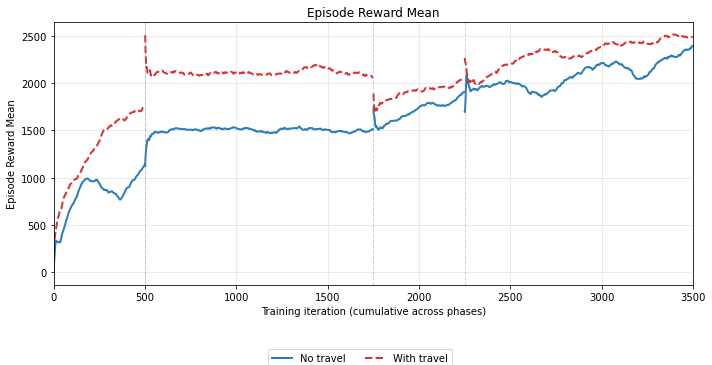

In [ ]:
fig = plotting.compare_training_curves(
    runs,
    metric="episode_reward_mean",
    short_labels=["No travel", "With travel"],
    smooth_window=5,
)

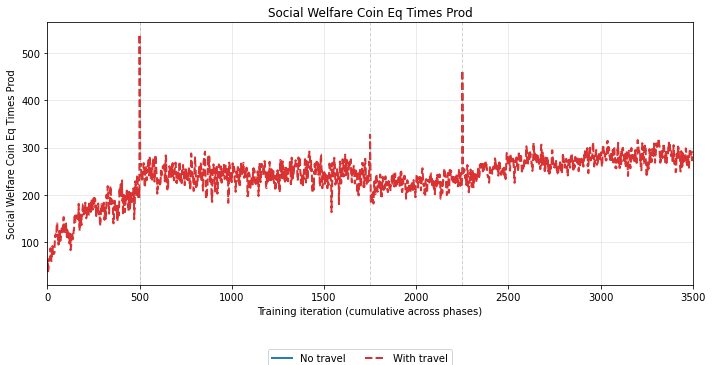

In [ ]:
fig = plotting.compare_training_curves(
    runs,
    metric="social_welfare_coin_eq_times_prod",
    short_labels=["No travel", "With travel"],
    smooth_window=5,
)

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,594.875,167.696632,222.51875,703,283,4759.0,0,6,2,travel-off__regionaltrade-off__layout-stacked_...,500,1250,500,1250
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,743.625,152.040979,265.31625,903,333,5949.0,48,6,2,travel-on__regionaltrade-off__layout-stacked_5...,500,1250,500,1250


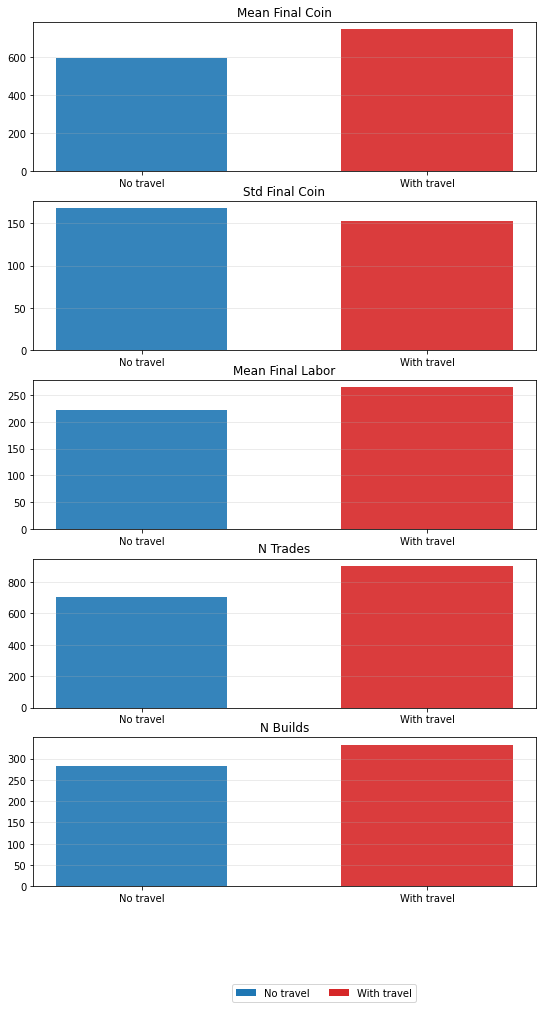

In [ ]:
fig_single, out_single = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar=None,  
)

out_single

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,594.875,167.696632,222.51875,703,283,4759.0,0,6,2,travel-off__regionaltrade-off__layout-stacked_...,500,1250,500,1250
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,743.625,152.040979,265.31625,903,333,5949.0,48,6,2,travel-on__regionaltrade-off__layout-stacked_5...,500,1250,500,1250


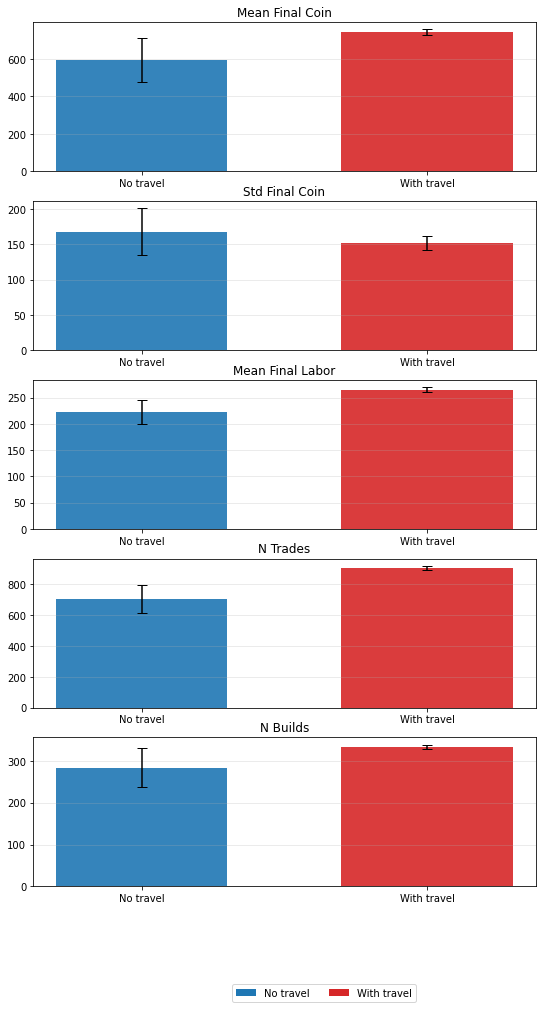

In [ ]:
fig_avg, out_avg = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar="std",  
)

out_avg

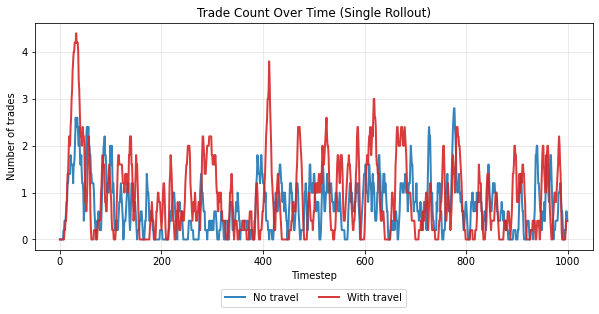

In [ ]:
fig_single = plotting.compare_trade_dynamics(
    runs,
    short_labels=["No travel", "With travel"],
    mode="single",
    smooth_window=5,  
)

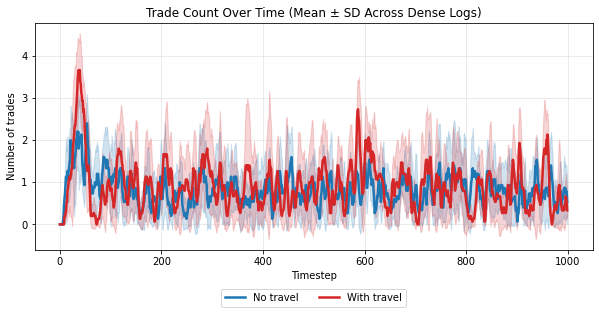

In [ ]:
fig_avg = plotting.compare_trade_dynamics(
    runs,
    short_labels=["No travel", "With travel"],
    mode="average",
    smooth_window=5,
)

,label,gini,error,n_dense_logs
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,0.146544,NaN,1
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,0.102630,NaN,1


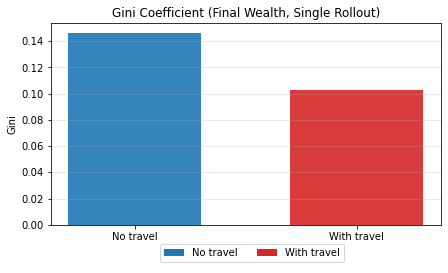

In [ ]:
fig_single, out_single = plotting.compare_gini(
    runs,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    mode="single",
    errorbar=None,
)

out_single

,label,gini,error,n_dense_logs
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,0.102995,0.034744,3
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,0.112826,0.008579,3


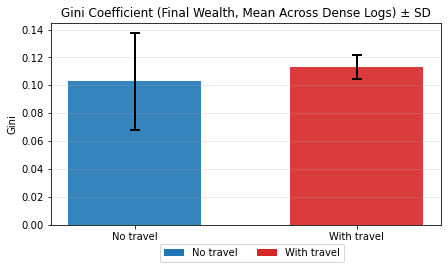

In [ ]:
fig_avg, out_avg = plotting.compare_gini(
    runs,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    mode="average",
    errorbar="std",
)

out_avg

In [ ]:
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

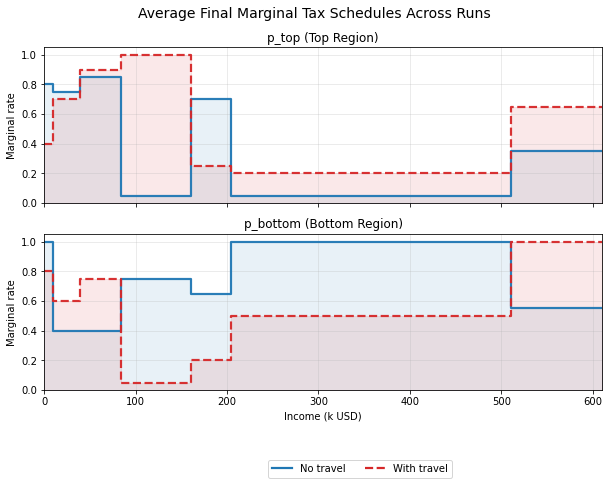

In [ ]:
runs_single = []
for r in runs:
    r_copy = r.copy()
    r_copy["dense_logs"] = {0: r["dense_log"]}  # only one log
    runs_single.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar=None,  
    last_bin_width=100,
)

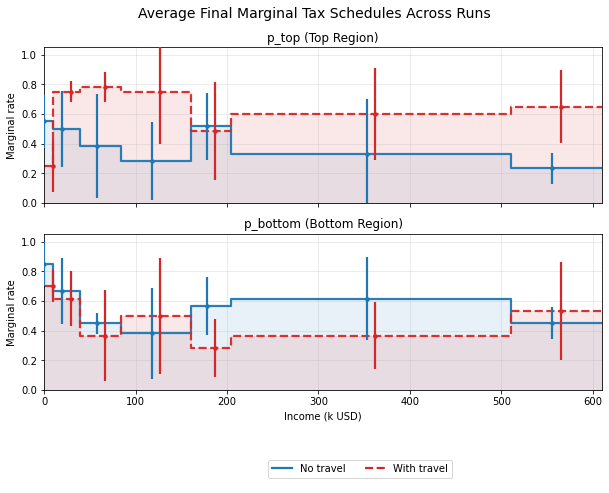

In [ ]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar="std",  
    last_bin_width=100,
)

# Figuring out agent movement

In [ ]:
df_agents, df_summary = plotting.diagnose_agent_activity_df(runs[0]["dense_log"])
df_agents

,agent,movement,coin,wood,stone,labor
0,0,738.0,774.578437,1.0,6.0,225.87
1,1,690.0,636.479687,1.0,7.0,217.51
2,2,494.0,512.367188,3.0,3.0,233.43
3,3,510.0,626.574687,0.0,0.0,199.44
4,4,815.0,797.025000,1.0,5.0,249.07
5,5,149.0,221.192500,28.0,5.0,94.02
6,6,778.0,631.701250,2.0,1.0,321.43
7,7,618.0,559.081250,9.0,2.0,239.38


In [ ]:
all_summaries = []

for run in runs:
    _, df_sum = plotting.diagnose_agent_activity_df(run["dense_log"])
    df_sum["run"] = run["name"]
    all_summaries.append(df_sum)

df_all = pd.concat(all_summaries, ignore_index=True)
df_all

,steps,n_builds,n_trades,n_gathers,avg_movement,total_coin,total_wood,total_stone,run
0,1000,283,703,423,599.00,4759.0,45.0,29.0,travel-off__regionaltrade-off__layout-stacked_...
1,1000,333,903,496,772.75,5949.0,59.0,14.0,travel-on__regionaltrade-off__layout-stacked_5...


In [ ]:
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

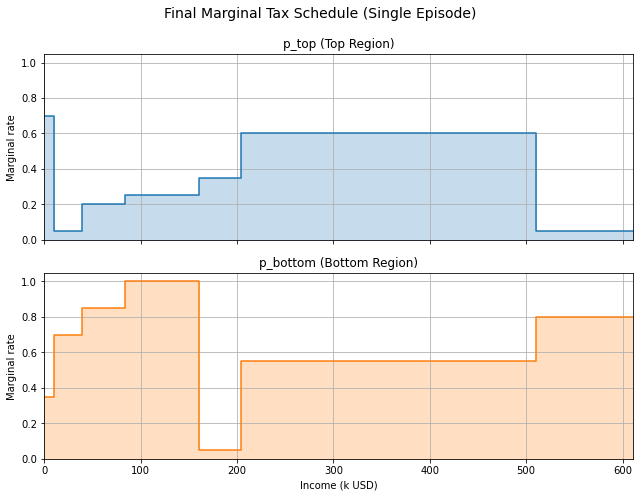

In [ ]:
single_dense_log = {0: dense_logs[0]}  # keep only episode 0

fig_single = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=single_dense_log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final Marginal Tax Schedule (Single Episode)",
    errorbar=None,  
    last_bin_width=100,
)

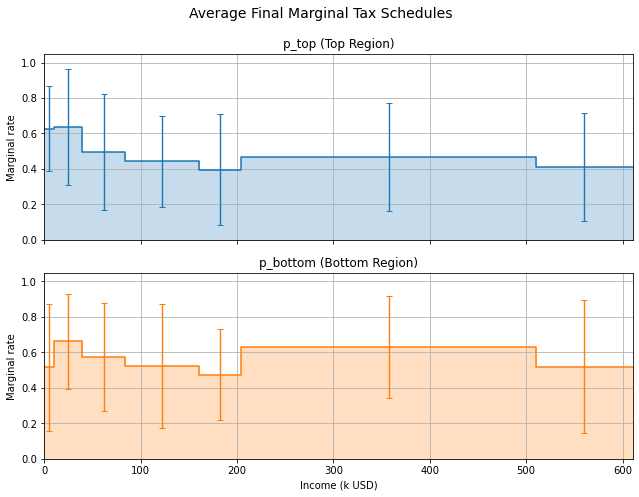

In [ ]:
fig_avg_final = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules",
    errorbar="std",
    last_bin_width=100, 
)

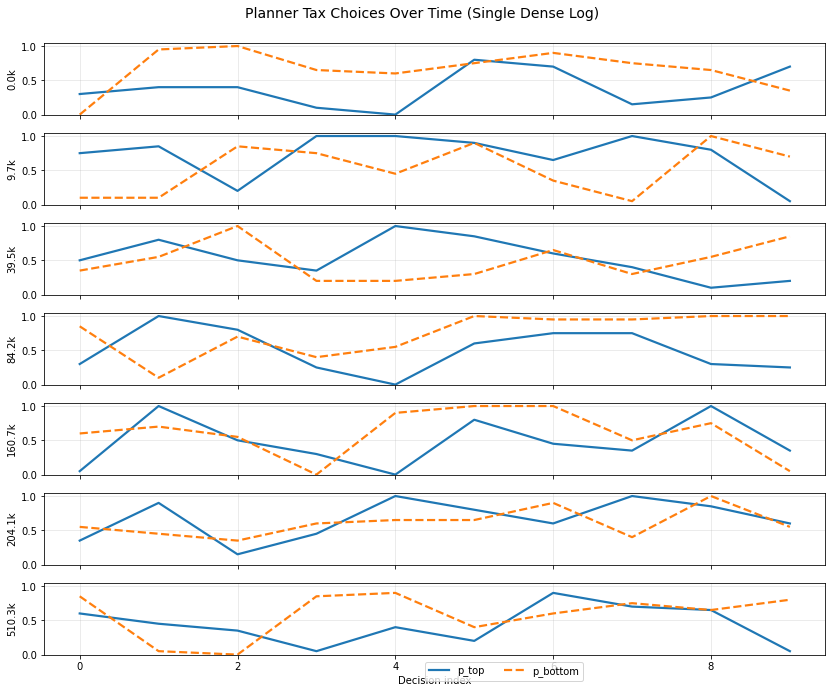

In [ ]:
fig_single = plotting.plot_planner_tax_lines(
    dense_logs={0: dense_logs[0]},
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="single",
    errorbar=None,
    title="Planner Tax Choices Over Time (Single Dense Log)"
)

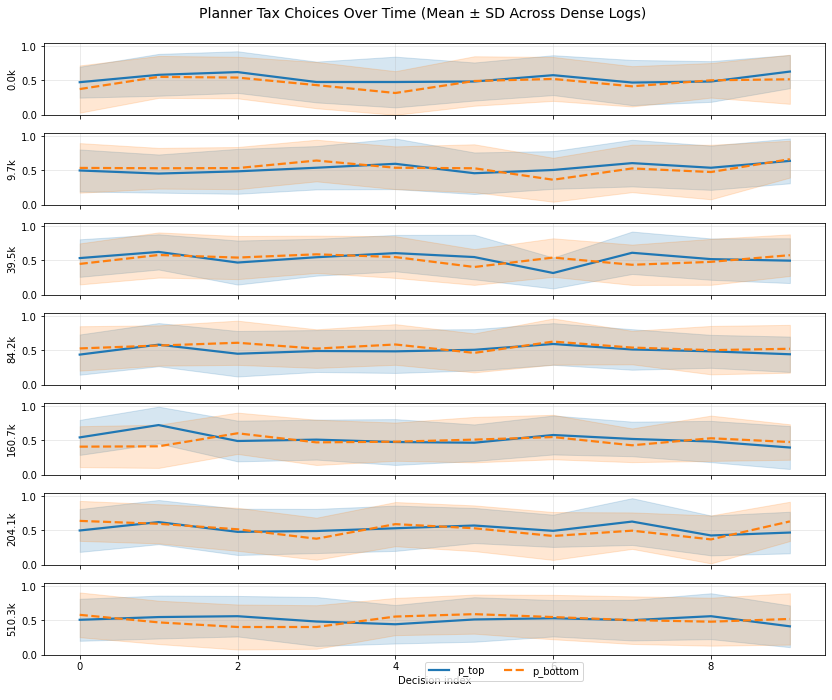

In [ ]:
fig_avg = plotting.plot_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="average",
    errorbar="std",
    title="Planner Tax Choices Over Time (Mean ± SD Across Dense Logs)"
)

In [ ]:
df_regions = plotting.agent_region_time_table(
    runs[0]["dense_log"],
    split_row=25,
    use_region_field=False,
    normalize=True,
)
df_regions

,timesteps_top,timesteps_bottom,total_timesteps,final_region,share_top,share_bottom
agent,,,,,,
0,1001,0,1001,top,1.0,0.0
1,1001,0,1001,top,1.0,0.0
2,1001,0,1001,top,1.0,0.0
3,1001,0,1001,top,1.0,0.0
4,0,1001,1001,bottom,0.0,1.0
5,0,1001,1001,bottom,0.0,1.0
6,0,1001,1001,bottom,0.0,1.0
7,0,1001,1001,bottom,0.0,1.0


In [ ]:
df_spells = plotting.agent_region_spell_table(
    runs[0]["dense_log"],
    split_row=25,
    use_region_field=False,
)
df_spells

,timesteps_top,timesteps_bottom,n_region_switches,n_top_spells,n_bottom_spells,avg_top_spell,avg_bottom_spell,avg_spell_overall,final_region
agent,,,,,,,,,
0,1001,0,0,1,0,1001.0,NaN,1001.0,top
1,1001,0,0,1,0,1001.0,NaN,1001.0,top
2,1001,0,0,1,0,1001.0,NaN,1001.0,top
3,1001,0,0,1,0,1001.0,NaN,1001.0,top
4,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
5,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
6,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
7,0,1001,0,0,1,NaN,1001.0,1001.0,bottom


# single agent single move

In [98]:
import numpy as np

def force_single_agent_move(env_obj, agent_id, target_region, max_tries=500):
    """
    Force a single agent to relocate once to a valid empty tile in the target region.
    Does not use the travel action or require CrossWaterTravel target attributes.
    """
    world = env_obj.env.world
    agent = world.agents[int(agent_id)]

    H, W = world.world_size
    split = H // 2

    if target_region == "top":
        r_min, r_max = 0, split
    elif target_region == "bottom":
        r_min, r_max = split + 1, H
    else:
        raise ValueError("target_region must be 'top' or 'bottom'")

    old_r, old_c = agent.loc

    # If already in target region, do nothing
    if (target_region == "top" and old_r < split) or (target_region == "bottom" and old_r > split):
        return {
            "agent": int(agent.idx),
            "from": (int(old_r), int(old_c)),
            "to": (int(old_r), int(old_c)),
            "new_region": target_region,
            "moved": False,
            "reason": "already_in_target_region",
        }

    # Try random valid locations in the target region
    for _ in range(max_tries):
        r = np.random.randint(r_min, r_max)
        c = np.random.randint(0, W)

        if world.maps.unoccupied[r, c] and world.can_agent_occupy(r, c, agent):
            new_r, new_c = world.set_agent_loc(agent, r, c)

            # update region state if present
            if "region" in agent.state:
                agent.state["region"] = "top" if int(new_r) < split else "bottom"

            # remove outstanding market listings/orders if supported
            try:
                cda = env_obj.env.get_component("ContinuousDoubleAuction")
                if cda is not None and hasattr(cda, "cancel_all_orders_for_agent"):
                    cda.cancel_all_orders_for_agent(agent.idx)
            except Exception:
                pass

            return {
                "agent": int(agent.idx),
                "from": (int(old_r), int(old_c)),
                "to": (int(new_r), int(new_c)),
                "new_region": agent.state.get("region", target_region),
                "moved": True,
            }

    raise RuntimeError(f"Could not find valid relocation target for agent {agent_id} to region {target_region}")

# def force_single_agent_move(env_obj, agent_id, target_region, max_tries=500):
#     """
#     Force a single agent to move across regions using the travel component logic.
#     Works with your CrossWaterTravel implementation.
#     """

#     world = env_obj.env.world

#     # Get travel component
#     travel_comp = None
#     for comp in world._components:
#         if comp.name == "CrossWaterTravel":
#             travel_comp = comp
#             break

#     if travel_comp is None:
#         raise ValueError("CrossWaterTravel component not found")

#     agent = world.agents[agent_id]

#     # Determine split (waterline)
#     split = world.world_size[0] // 2

#     # Determine target row based on region
#     if target_region == "top":
#         desired_r = split - 2
#     elif target_region == "bottom":
#         desired_r = split + 2
#     else:
#         raise ValueError("target_region must be 'top' or 'bottom'")

#     # Keep column roughly same
#     desired_c = int(agent.loc[1])

#     # Use your own helper (this exists in your code)
#     target = travel_comp._find_valid_target(agent, desired_r, desired_c)

#     if target is None:
#         raise RuntimeError("Could not find valid travel target")

#     # Move agent
#     new_r, new_c = world.set_agent_loc(agent, target[0], target[1])

#     # Update region state (IMPORTANT)
#     agent.state["region"] = travel_comp._region_from_row(new_r)

#     print(f"[FORCED MOVE] Agent {agent_id}: {agent.loc} -> {(new_r, new_c)}")

In [99]:
def generate_rollout_with_forced_move(
    trainer,
    env_obj,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
):
    def _compute_action(pid, obs, state):
        out = trainer.compute_action(
            observation=obs,
            state=state,
            policy_id=pid,
            full_fetch=False,
            explore=explore,
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    obs = env_obj.reset(force_dense_logging=True)

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    forced_move_log = None
    agent_utility_history = []

    for t in range(env_obj.env.episode_length):
        actions = {}

        for i in range(env_obj.env.n_agents):
            aid = str(i)
            a, ns = _compute_action("a", obs[aid], agent_states[aid])
            actions[aid] = a
            agent_states[aid] = ns

        a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
        a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
        actions["p_top"] = a_top
        actions["p_bottom"] = a_bottom

        obs, rew, done, info = env_obj.step(actions)

        if t == forced_timestep:
            forced_move_log = force_single_agent_move(
                env_obj=env_obj,
                agent_id=forced_agent_id,
                target_region=forced_target_region,
            )
            forced_move_log["timestep"] = t

        util_t = {}
        for agent in env_obj.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_obj.env.curr_optimization_metric.get(agent.idx, np.nan))
        agent_utility_history.append(util_t)

        if done.get("__all__", False):
            break

    dense_log = dict(env_obj.env.dense_log)

    if "states" in dense_log:
        n_states = len(dense_log["states"])
        n_utils = len(agent_utility_history)
        n_match = min(n_states, n_utils)

        for tt in range(n_match):
            for aid, util in agent_utility_history[tt].items():
                if aid in dense_log["states"][tt]:
                    dense_log["states"][tt][aid]["utility"] = util

    dense_log["forced_move"] = forced_move_log
    return dense_log

In [100]:
forced_log = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)


=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'0': {'delta': -1.2039999999999935, 'before_pos': (28, 13), 'after_pos': (28, 13), 'dynamic_region_after': 'bottom'}, '4': {'delta': 0.30100000000000193, 'before_pos': (37, 0), 'after_pos': (37, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.301, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'}, '6': {'delta': 0.301, 'before_pos': (26, 13), 'after_pos': (26, 13), 'dynamic_region_after': 'bottom'}, '7': {'delta': 0.301, 'before_pos': (50, 13), 'after_pos': (50, 13), 'dynamic_region_after': 'bottom'}}
OK: all affected agents are in the planner's expected region.

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'0': {'delta': 0.6209999999999951, 'before_pos': (28, 13), 'after_pos': (28, 13), 'dynamic_region_after': 'bottom'}, '

In [101]:
def get_forced_move_info(log):
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")
    return fm["agent"], fm.get("timestep", None), fm

In [125]:
import numpy as np
import pandas as pd

def forced_move_agent_summary(log, window_before=100, window_after=100):
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    agent_id = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    t_start_before = max(0, t0 - window_before)
    t_end_before = t0
    t_start_after = t0 + 1
    t_end_after = min(len(states), t0 + 1 + window_after)

    aid = str(agent_id)

    def coin_at(t):
        s = states[t][aid]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor_at(t):
        return states[t][aid]["endogenous"]["Labor"]

    def utility_series(t1, t2):
        vals = []
        for t in range(t1, t2):
            vals.append(states[t][aid].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def count_builds(t1, t2):
        n = 0
        income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t1 <= t < t2):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) == agent_id:
                    n += 1
                    income += float(b.get("income", 0.0))
        return n, income

    def count_trades(t1, t2):
        out = {
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
            "trade_cashflow": 0.0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t1 <= t < t2):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                commodity = tr["commodity"]
                if int(tr["buyer"]) == agent_id:
                    out[f"n_buy_{commodity.lower()}"] += 1
                    out["trade_cashflow"] -= float(tr["cost"])
                if int(tr["seller"]) == agent_id:
                    out[f"n_sell_{commodity.lower()}"] += 1
                    out["trade_cashflow"] += float(tr["income"])
        return out

    coin_before = coin_at(t_end_before - 1) - coin_at(t_start_before)
    coin_after = coin_at(t_end_after - 1) - coin_at(t_start_after)

    labor_before = labor_at(t_end_before - 1) - labor_at(t_start_before)
    labor_after = labor_at(t_end_after - 1) - labor_at(t_start_after)

    util_before = utility_series(t_start_before, t_end_before)
    util_after = utility_series(t_start_after, t_end_after)

    n_build_before, build_inc_before = count_builds(t_start_before, t_end_before)
    n_build_after, build_inc_after = count_builds(t_start_after, t_end_after)

    trade_before = count_trades(t_start_before, t_end_before)
    trade_after = count_trades(t_start_after, t_end_after)

    df = pd.DataFrame([
        {
            "period": "before_move",
            "agent": agent_id,
            "t_start": t_start_before,
            "t_end": t_end_before - 1,
            "coin_change": coin_before,
            "labor_change": labor_before,
            "avg_utility": np.nanmean(util_before),
            "n_builds": n_build_before,
            "build_income": build_inc_before,
            **trade_before,
        },
        {
            "period": "after_move",
            "agent": agent_id,
            "t_start": t_start_after,
            "t_end": t_end_after - 1,
            "coin_change": coin_after,
            "labor_change": labor_after,
            "avg_utility": np.nanmean(util_after),
            "n_builds": n_build_after,
            "build_income": build_inc_after,
            **trade_after,
        },
    ])

    return df

In [126]:
df_move_summary = forced_move_agent_summary(forced_log, window_before=100, window_after=100)
df_move_summary

,period,agent,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,trade_cashflow
0,before_move,0,100,199,33.000,16.12,3.839189,3,33.0,0,0,0,0,0.0
1,after_move,0,201,300,45.796,12.20,26.950222,5,55.0,1,0,1,0,-8.0


In [104]:
def forced_move_event_table(log, window=100):
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    agent_id = int(fm["agent"])
    t0 = int(fm["timestep"])

    rows = []

    for t in range(max(0, t0 - window), min(len(log["states"]), t0 + window + 1)):
        state = log["states"][t][str(agent_id)]

        row = {
            "t": t,
            "relative_t": t - t0,
            "region": state.get("region", np.nan),
            "coin": state["inventory"]["Coin"] + state["escrow"]["Coin"],
            "wood": state["inventory"]["Wood"] + state["escrow"]["Wood"],
            "stone": state["inventory"]["Stone"] + state["escrow"]["Stone"],
            "labor": state["endogenous"]["Labor"],
            "utility": state.get("utility", np.nan),
            "built": 0,
            "bought_wood": 0,
            "sold_wood": 0,
            "bought_stone": 0,
            "sold_stone": 0,
        }

        if "Build" in log and t < len(log["Build"]):
            builds = log["Build"][t]
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) == agent_id:
                    row["built"] += 1

        if "Trade" in log and t < len(log["Trade"]):
            trades = log["Trade"][t]
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                commodity = tr["commodity"].lower()
                if int(tr["buyer"]) == agent_id:
                    row[f"bought_{commodity}"] += 1
                if int(tr["seller"]) == agent_id:
                    row[f"sold_{commodity}"] += 1

        rows.append(row)

    return pd.DataFrame(rows)

In [105]:
df_move_events = forced_move_event_table(forced_log, window=80)
df_move_events.head(20)
df_move_events.tail(20)

,t,relative_t,region,coin,wood,stone,labor,utility,built,bought_wood,sold_wood,bought_stone,sold_stone
141,261,61,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
142,262,62,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
143,263,63,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
144,264,64,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
145,265,65,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
146,266,66,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
147,267,67,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
148,268,68,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
149,269,69,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
150,270,70,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0


In [106]:
import matplotlib.pyplot as plt

def plot_forced_move_timeseries(log, window=100):
    df = forced_move_event_table(log, window=window)
    fm = log["forced_move"]
    agent_id = fm["agent"]

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    axes[0].plot(df["relative_t"], df["coin"], label="Coin")
    axes[0].plot(df["relative_t"], df["utility"], label="Utility")
    axes[0].axvline(0, linestyle="--")
    axes[0].set_title(f"Agent {agent_id}: coin and utility around forced move")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(df["relative_t"], df["wood"], label="Wood")
    axes[1].plot(df["relative_t"], df["stone"], label="Stone")
    axes[1].axvline(0, linestyle="--")
    axes[1].set_title("Inventory")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(df["relative_t"], df["labor"], label="Labor")
    axes[2].axvline(0, linestyle="--")
    axes[2].set_title("Labor")
    axes[2].grid(True)

    axes[3].plot(df["relative_t"], df["bought_wood"] + df["sold_wood"], label="Wood trades")
    axes[3].plot(df["relative_t"], df["bought_stone"] + df["sold_stone"], label="Stone trades")
    axes[3].plot(df["relative_t"], df["built"], label="Builds")
    axes[3].axvline(0, linestyle="--")
    axes[3].set_title("Economic activity")
    axes[3].set_xlabel("Timesteps relative to forced move")
    axes[3].legend()
    axes[3].grid(True)

    fig.tight_layout()
    return fig

In [107]:
forced_log_200 = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

forced_log_400 = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

forced_log_600 = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=600,
    forced_target_region="bottom",
    explore=False,
)


=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -2.7787500000000023, 'before_pos': (33, 0), 'after_pos': (33, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.92625, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'}, '6': {'delta': 0.92625, 'before_pos': (26, 13), 'after_pos': (26, 13), 'dynamic_region_after': 'bottom'}, '7': {'delta': 0.92625, 'before_pos': (50, 13), 'after_pos': (50, 13), 'dynamic_region_after': 'bottom'}}
OK: all affected agents are in the planner's expected region.

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -2.8846874999999983, 'before_pos': (32, 1), 'after_pos': (32, 1), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.9615624999999998, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'},

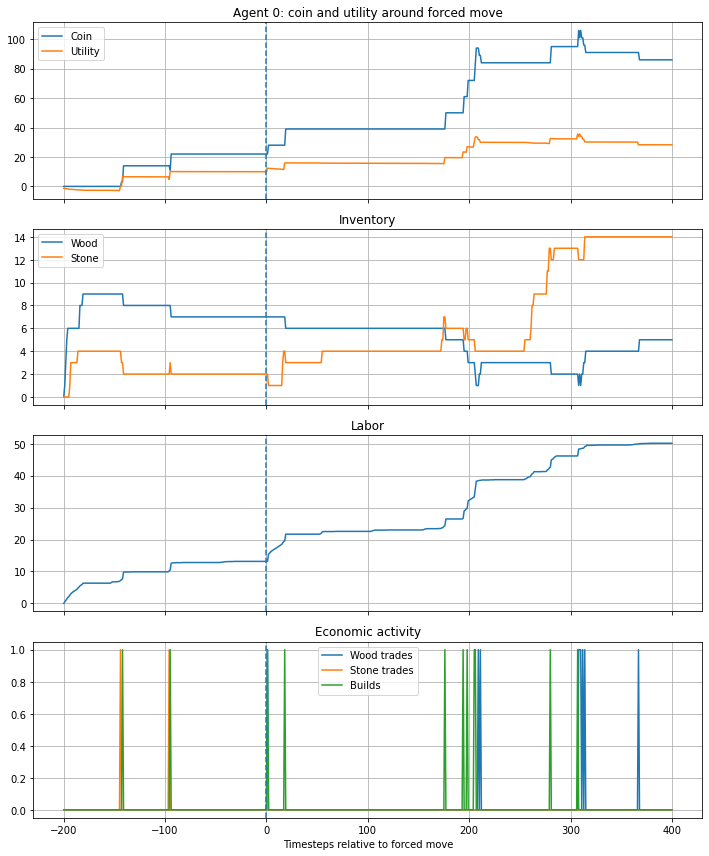

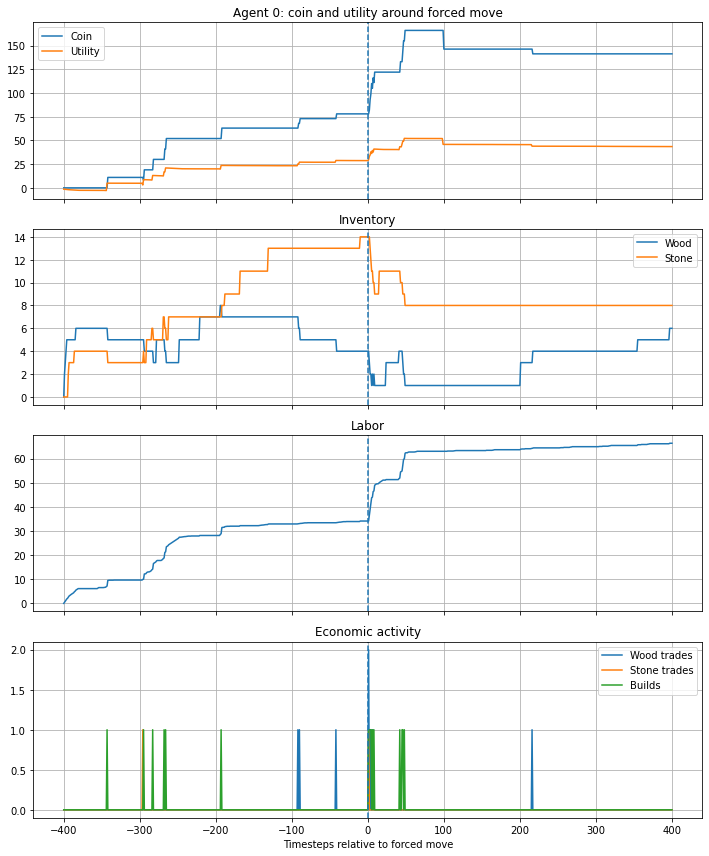

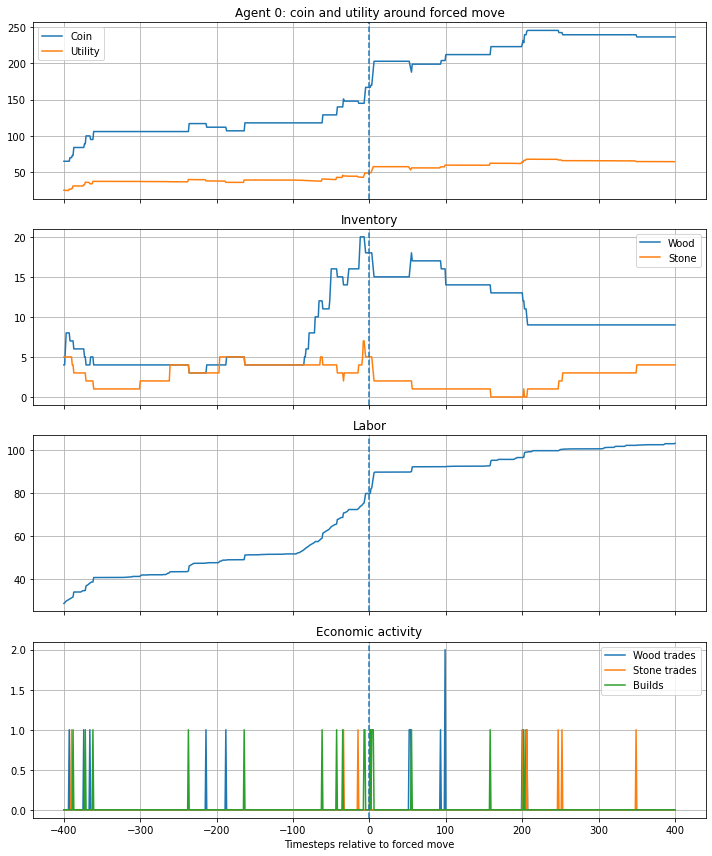

In [108]:
fig = plot_forced_move_timeseries(forced_log_200, window=400)
fig = plot_forced_move_timeseries(forced_log_400, window=400)
fig = plot_forced_move_timeseries(forced_log_600, window=400)

In [127]:
import numpy as np
import pandas as pd

def forced_move_system_summary_table(log, window_before=100, window_after=100):
    """
    Summary table for moved agent, other agents, and both planners
    before vs after a forced move.

    Returns a pandas DataFrame.
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out



    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                "n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
                "avg_planner_reward": np.nan,
                "sum_planner_reward": np.nan,
            })


    return pd.DataFrame(rows)

In [128]:
df_system = forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_system

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1,100,199,33.000,16.12,3.839189,3,33.0,0,0.0,0,0,0,0,NaN,NaN
1,moved_agent,after_move,1,201,300,45.796,12.20,26.950222,5,55.0,2,-8.0,1,0,1,0,NaN,NaN
2,other_agents,before_move,7,100,199,55.000,22.44,2.498209,4,55.0,0,0.0,0,0,0,0,NaN,NaN
3,other_agents,after_move,7,201,300,64.204,17.91,5.966774,4,55.0,10,8.0,0,1,4,5,NaN,NaN


In [ ]:
import numpy as np
import pandas as pd

def baseline_system_summary_table(log, moved_agent, reference_timestep, window_before=100, window_after=100, episode_key=0):
    """
    Summary table for the original baseline run with NO forced move.
    Accepts either:
      - a single episode log with log["states"], or
      - a dict of episode logs, e.g. log[0]["states"].

    Parameters
    ----------
    log : dict
    moved_agent : int
    reference_timestep : int
    window_before : int
    window_after : int
    episode_key : int or str
        Which episode to use if log is a multi-episode dict.
    """

    # --- normalize to a single episode log ---
    if "states" in log:
        ep_log = log
    elif episode_key in log and isinstance(log[episode_key], dict) and "states" in log[episode_key]:
        ep_log = log[episode_key]
    else:
        # fallback: pick first entry that looks like an episode log
        ep_log = None
        for v in log.values():
            if isinstance(v, dict) and "states" in v:
                ep_log = v
                break
        if ep_log is None:
            raise ValueError("Could not find a single episode log with key 'states'.")

    t0 = int(reference_timestep)

    states = ep_log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    if moved_agent not in agent_ids:
        raise ValueError(f"moved_agent={moved_agent} not found in baseline log")

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(ep_log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(ep_log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out

    def planner_stats(pid, t_start, t_end):
        arr = np.array(ep_log.get("planner_rewards", {}).get(pid, []), dtype=float)
        if len(arr) == 0:
            return {"avg_planner_reward": np.nan, "sum_planner_reward": np.nan}

        t_start = min(t_start, len(arr))
        t_end = min(t_end, len(arr))
        if t_start >= t_end:
            return {"avg_planner_reward": np.nan, "sum_planner_reward": np.nan}

        seg = arr[t_start:t_end]
        return {
            "avg_planner_reward": float(np.nanmean(seg)),
            "sum_planner_reward": float(np.nansum(seg)),
        }

    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                "n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
                "avg_planner_reward": np.nan,
                "sum_planner_reward": np.nan,
            })

    for pid in ["p_top", "p_bottom"]:
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            pr = planner_stats(pid, t_start, t_end)
            rows.append({
                "group": pid,
                "period": period_name,
                "n_agents": np.nan,
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": np.nan,
                "labor_change": np.nan,
                "avg_utility": np.nan,
                "n_builds": np.nan,
                "build_income": np.nan,
                "n_trades": np.nan,
                "trade_cashflow": np.nan,
                "n_buy_wood": np.nan, 
                "n_sell_wood": np.nan,
                "n_buy_stone": np.nan,
                "n_sell_stone": np.nan,
                **pr,
            })

    return pd.DataFrame(rows)

In [ ]:
# use the same moved agent and timestep as in the forced-move run
moved_agent = forced_log["forced_move"]["agent"]
reference_timestep = forced_log["forced_move"]["timestep"]

df_forced = forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_baseline = baseline_system_summary_table(
    dense_logs,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)

df_baseline

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1.0,100,199,107.000,29.95,31.780025,6.0,66.0,20.0,44.0,1.0,12.0,4.0,3.0,NaN,NaN
1,moved_agent,after_move,1.0,201,300,87.105,29.17,54.730091,5.0,55.0,14.0,40.0,0.0,9.0,3.0,2.0,NaN,NaN
2,other_agents,before_move,7.0,100,199,201.000,127.34,6.624568,19.0,255.0,68.0,-44.0,31.0,20.0,8.0,9.0,NaN,NaN
3,other_agents,after_move,7.0,201,300,346.895,150.07,26.730850,26.0,379.0,138.0,-40.0,44.0,35.0,29.0,30.0,NaN,NaN
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.298650,29.865000
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.510383,51.038333
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314063,31.406276
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.433304,43.330417


In [135]:
df_forced_cmp = df_forced.copy()
df_forced_cmp["run_type"] = "forced_move"

df_baseline_cmp = df_baseline.copy()
df_baseline_cmp["run_type"] = "baseline"

df_compare = pd.concat([df_baseline_cmp, df_forced_cmp], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,100,199,107.000,29.95,31.780025,6.0,66.0,20.0,44.0,1.0,12.0,4.0,3.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,201,300,87.105,29.17,54.730091,5.0,55.0,14.0,40.0,0.0,9.0,3.0,2.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,100,199,201.000,127.34,6.624568,19.0,255.0,68.0,-44.0,31.0,20.0,8.0,9.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,201,300,346.895,150.07,26.730850,26.0,379.0,138.0,-40.0,44.0,35.0,29.0,30.0,NaN,NaN,baseline
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.298650,29.865000,baseline
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.510383,51.038333,baseline
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314063,31.406276,baseline
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.433304,43.330417,baseline
8,moved_agent,before_move,1.0,100,199,33.000,16.12,3.839189,3.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,201,300,45.796,12.20,26.950222,5.0,55.0,2.0,-8.0,1.0,0.0,1.0,0.0,NaN,NaN,forced_move


In [142]:
import copy

def _compute_actions_from_obs(trainer, env_obj, obs, agent_states, p_top_state, p_bottom_state, explore=False):
    def _compute_action(pid, obs_i, state):
        out = trainer.compute_action(
            observation=obs_i,
            state=state,
            policy_id=pid,
            full_fetch=False,
            explore=explore,
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    actions = {}

    for i in range(env_obj.env.n_agents):
        aid = str(i)
        a, ns = _compute_action("a", obs[aid], agent_states[aid])
        actions[aid] = a
        agent_states[aid] = ns

    a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
    a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)

    actions["p_top"] = a_top
    actions["p_bottom"] = a_bottom

    return actions, agent_states, p_top_state, p_bottom_state

In [143]:
def _inject_utility_into_dense_log(dense_log, agent_utility_history):
    if "states" not in dense_log:
        return dense_log

    n_states = len(dense_log["states"])
    n_utils = len(agent_utility_history)
    n_match = min(n_states, n_utils)

    for t in range(n_match):
        for aid, util in agent_utility_history[t].items():
            if aid in dense_log["states"][t]:
                dense_log["states"][t][aid]["utility"] = util

    return dense_log

In [144]:
def force_single_agent_move(env_obj, agent_id, target_region, max_tries=500):
    world = env_obj.env.world
    agent = world.agents[int(agent_id)]

    H, W = world.world_size
    split = H // 2

    if target_region == "top":
        r_min, r_max = 0, split
    elif target_region == "bottom":
        r_min, r_max = split + 1, H
    else:
        raise ValueError("target_region must be 'top' or 'bottom'")

    old_r, old_c = agent.loc

    if (target_region == "top" and old_r < split) or (target_region == "bottom" and old_r > split):
        return {
            "agent": int(agent.idx),
            "from": (int(old_r), int(old_c)),
            "to": (int(old_r), int(old_c)),
            "new_region": target_region,
            "moved": False,
            "reason": "already_in_target_region",
        }

    for _ in range(max_tries):
        r = np.random.randint(r_min, r_max)
        c = np.random.randint(0, W)

        if world.maps.unoccupied[r, c] and world.can_agent_occupy(r, c, agent):
            new_r, new_c = world.set_agent_loc(agent, r, c)

            if "region" in agent.state:
                agent.state["region"] = "top" if int(new_r) < split else "bottom"

            try:
                cda = env_obj.env.get_component("ContinuousDoubleAuction")
                if cda is not None and hasattr(cda, "cancel_all_orders_for_agent"):
                    cda.cancel_all_orders_for_agent(agent.idx)
            except Exception:
                pass

            return {
                "agent": int(agent.idx),
                "from": (int(old_r), int(old_c)),
                "to": (int(new_r), int(new_c)),
                "new_region": agent.state.get("region", target_region),
                "moved": True,
            }

    raise RuntimeError(f"Could not find valid relocation target for agent {agent_id} to region {target_region}")

In [145]:
def generate_paired_baseline_forced_rollouts(
    trainer,
    env_obj,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
):
    """
    Create two rollouts with identical pre-move trajectories:
      1) baseline continuation
      2) forced-move continuation

    Returns
    -------
    baseline_log, forced_log
    """

    # --- reset once ---
    obs = env_obj.reset(force_dense_logging=True)

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    pre_move_utility_history = []
    pre_move_planner_rewards_top = []
    pre_move_planner_rewards_bottom = []

    # --- run until forced_timestep ---
    for t in range(forced_timestep + 1):
        actions, agent_states, p_top_state, p_bottom_state = _compute_actions_from_obs(
            trainer, env_obj, obs, agent_states, p_top_state, p_bottom_state, explore=explore
        )

        obs, rew, done, info = env_obj.step(actions)

        util_t = {}
        for agent in env_obj.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_obj.env.curr_optimization_metric.get(agent.idx, np.nan))
        pre_move_utility_history.append(util_t)

        pre_move_planner_rewards_top.append(rew.get("p_top", np.nan))
        pre_move_planner_rewards_bottom.append(rew.get("p_bottom", np.nan))

        if done.get("__all__", False):
            raise RuntimeError("Episode ended before forced_timestep; choose a smaller forced_timestep.")

    # --- snapshot branch point ---
    env_baseline = copy.deepcopy(env_obj)
    env_forced = copy.deepcopy(env_obj)

    obs_baseline = copy.deepcopy(obs)
    obs_forced = copy.deepcopy(obs)

    agent_states_baseline = copy.deepcopy(agent_states)
    agent_states_forced = copy.deepcopy(agent_states)

    p_top_state_baseline = copy.deepcopy(p_top_state)
    p_top_state_forced = copy.deepcopy(p_top_state)

    p_bottom_state_baseline = copy.deepcopy(p_bottom_state)
    p_bottom_state_forced = copy.deepcopy(p_bottom_state)

    # =========================
    # BASELINE continuation
    # =========================
    baseline_utility_history = copy.deepcopy(pre_move_utility_history)
    baseline_top_rewards = copy.deepcopy(pre_move_planner_rewards_top)
    baseline_bottom_rewards = copy.deepcopy(pre_move_planner_rewards_bottom)

    for t in range(forced_timestep + 1, env_baseline.env.episode_length):
        actions, agent_states_baseline, p_top_state_baseline, p_bottom_state_baseline = _compute_actions_from_obs(
            trainer,
            env_baseline,
            obs_baseline,
            agent_states_baseline,
            p_top_state_baseline,
            p_bottom_state_baseline,
            explore=explore,
        )

        obs_baseline, rew, done, info = env_baseline.step(actions)

        util_t = {}
        for agent in env_baseline.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_baseline.env.curr_optimization_metric.get(agent.idx, np.nan))
        baseline_utility_history.append(util_t)

        baseline_top_rewards.append(rew.get("p_top", np.nan))
        baseline_bottom_rewards.append(rew.get("p_bottom", np.nan))

        if done.get("__all__", False):
            break

    baseline_log = dict(env_baseline.env.dense_log)
    baseline_log = _inject_utility_into_dense_log(baseline_log, baseline_utility_history)
    baseline_log["planner_rewards"] = {
        "p_top": baseline_top_rewards,
        "p_bottom": baseline_bottom_rewards,
    }
    baseline_log["paired_reference"] = {
        "agent": int(forced_agent_id),
        "timestep": int(forced_timestep),
        "target_region": forced_target_region,
        "type": "baseline",
    }

    # =========================
    # FORCED continuation
    # =========================
    forced_utility_history = copy.deepcopy(pre_move_utility_history)
    forced_top_rewards = copy.deepcopy(pre_move_planner_rewards_top)
    forced_bottom_rewards = copy.deepcopy(pre_move_planner_rewards_bottom)

    move_log = force_single_agent_move(
        env_forced,
        agent_id=forced_agent_id,
        target_region=forced_target_region,
    )
    move_log["timestep"] = int(forced_timestep)

    for t in range(forced_timestep + 1, env_forced.env.episode_length):
        actions, agent_states_forced, p_top_state_forced, p_bottom_state_forced = _compute_actions_from_obs(
            trainer,
            env_forced,
            obs_forced,
            agent_states_forced,
            p_top_state_forced,
            p_bottom_state_forced,
            explore=explore,
        )

        obs_forced, rew, done, info = env_forced.step(actions)

        util_t = {}
        for agent in env_forced.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_forced.env.curr_optimization_metric.get(agent.idx, np.nan))
        forced_utility_history.append(util_t)

        forced_top_rewards.append(rew.get("p_top", np.nan))
        forced_bottom_rewards.append(rew.get("p_bottom", np.nan))

        if done.get("__all__", False):
            break

    forced_log = dict(env_forced.env.dense_log)
    forced_log = _inject_utility_into_dense_log(forced_log, forced_utility_history)
    forced_log["planner_rewards"] = {
        "p_top": forced_top_rewards,
        "p_bottom": forced_bottom_rewards,
    }
    forced_log["forced_move"] = move_log

    return baseline_log, forced_log

In [146]:
paired_baseline_log, paired_forced_log = generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)


=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -0.678750000000008, 'before_pos': (33, 0), 'after_pos': (33, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.22624999999999995, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'}, '6': {'delta': 0.22625000000000028, 'before_pos': (26, 13), 'after_pos': (26, 13), 'dynamic_region_after': 'bottom'}, '7': {'delta': 0.22624999999999995, 'before_pos': (50, 13), 'after_pos': (50, 13), 'dynamic_region_after': 'bottom'}}
OK: all affected agents are in the planner's expected region.

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -0.678750000000008, 'before_pos': (27, 0), 'after_pos': (27, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.22624999999999995, 'before_pos': (50, 0), 'after_pos': (50, 0),

In [147]:
df_forced = forced_move_system_summary_table(
    paired_forced_log,
    window_before=100,
    window_after=100,
)
df_forced["run_type"] = "forced_move"

In [148]:
moved_agent = paired_forced_log["forced_move"]["agent"]
reference_timestep = paired_forced_log["forced_move"]["timestep"]

df_baseline = baseline_system_summary_table(
    paired_baseline_log,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)
df_baseline["run_type"] = "baseline"

In [149]:
df_compare = pd.concat([df_baseline, df_forced], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,100,199,6.000,7.98,19.618940,1.0,11.0,1.0,-5.0,1.0,0.0,0.0,0.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,201,300,0.000,1.42,19.692551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,100,199,16.000,14.13,1.519337,1.0,11.0,1.0,5.0,0.0,1.0,0.0,0.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,201,300,44.000,27.19,2.175486,4.0,44.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,baseline
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.887379e-16,1.887379e-14,baseline
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,baseline
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.333333e-03,8.333333e-01,baseline
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.262500e-03,2.262500e-01,baseline
8,moved_agent,before_move,1.0,100,199,6.000,7.98,19.618940,1.0,11.0,1.0,-5.0,1.0,0.0,0.0,0.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,201,300,49.297,13.71,33.766314,5.0,55.0,2.0,-4.0,1.0,1.0,0.0,0.0,NaN,NaN,forced_move


In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_forced_move_utilities_system(log, window=100):
    """
    Plot utility development before and after forced move for:
    - moved agent
    - average of other agents
    - p_top reward
    - p_bottom reward
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())
    other_agents = [aid for aid in agent_ids if aid != moved_agent]

    t_start = max(0, t0 - window)
    t_end = min(len(states), t0 + window + 1)

    rows = []
    for t in range(t_start, t_end):
        rel_t = t - t0

        moved_u = states[t][str(moved_agent)].get("utility", np.nan)

        others_u = []
        for aid in other_agents:
            others_u.append(states[t][str(aid)].get("utility", np.nan))
        others_u = np.array(others_u, dtype=float)

        p_top_arr = np.array(log.get("planner_rewards", {}).get("p_top", []), dtype=float)
        p_bottom_arr = np.array(log.get("planner_rewards", {}).get("p_bottom", []), dtype=float)

        p_top_val = p_top_arr[t] if t < len(p_top_arr) else np.nan
        p_bottom_val = p_bottom_arr[t] if t < len(p_bottom_arr) else np.nan

        rows.append({
            "t": t,
            "relative_t": rel_t,
            "moved_agent_utility": moved_u,
            "other_agents_avg_utility": float(np.nanmean(others_u)),
            "p_top_reward": p_top_val,
            "p_bottom_reward": p_bottom_val,
        })

    df = pd.DataFrame(rows)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(df["relative_t"], df["moved_agent_utility"], label="Moved agent utility")
    axes[0].plot(df["relative_t"], df["other_agents_avg_utility"], label="Other agents avg utility")
    axes[0].axvline(0, linestyle="--")
    axes[0].set_title("Agent utility before and after forced move")
    axes[0].set_ylabel("Utility")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(df["relative_t"], df["p_top_reward"], label="p_top reward")
    axes[1].plot(df["relative_t"], df["p_bottom_reward"], label="p_bottom reward")
    axes[1].axvline(0, linestyle="--")
    axes[1].set_title("Planner rewards before and after forced move")
    axes[1].set_xlabel("Timesteps relative to forced move")
    axes[1].set_ylabel("Reward")
    axes[1].grid(True)
    axes[1].legend()

    fig.tight_layout()
    return fig, df

,t,relative_t,moved_agent_utility,other_agents_avg_utility,p_top_reward,p_bottom_reward
0,100,-100,-2.831701,0.334971,NaN,NaN
1,101,-99,-2.831701,0.334971,NaN,NaN
2,102,-98,-2.831701,0.334971,NaN,NaN
3,103,-97,-2.842201,0.319371,NaN,NaN
4,104,-96,-2.852701,0.311571,NaN,NaN


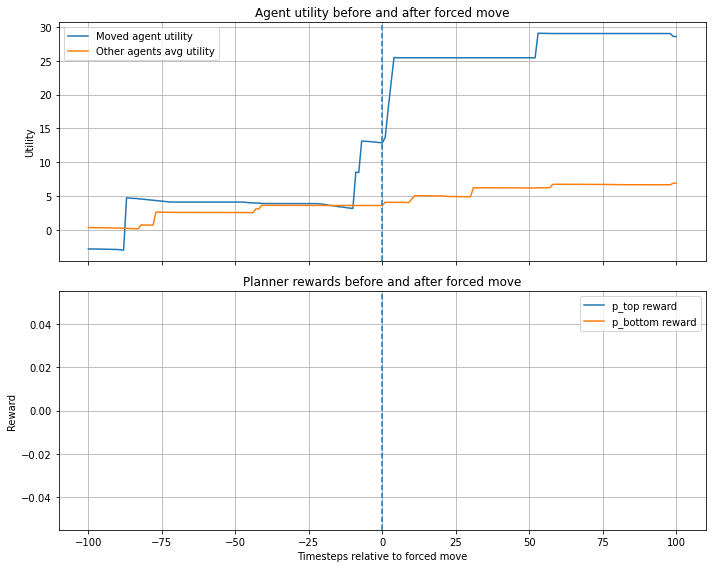

In [123]:
fig, df_util = plot_forced_move_utilities_system(forced_log, window=100)
df_util.head()

In [113]:
def forced_move_delta_table(log, window_before=100, window_after=100):
    df = forced_move_system_summary_table(
        log,
        window_before=window_before,
        window_after=window_after,
    )

    numeric_cols = [
        c for c in df.columns
        if c not in ["group", "period"]
    ]

    before = df[df["period"] == "before_move"].set_index("group")
    after = df[df["period"] == "after_move"].set_index("group")

    delta = after[numeric_cols] - before[numeric_cols]
    delta = delta.reset_index()
    return delta

In [114]:
df_delta = forced_move_delta_table(forced_log, window_before=100, window_after=100)
df_delta

,group,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,0.0,101,101,12.796,-3.92,23.111032,2.0,22.0,2.0,-8.0,1.0,0.0,1.0,0.0,NaN,NaN
1,other_agents,0.0,101,101,9.204,-4.53,3.468566,0.0,0.0,10.0,8.0,0.0,1.0,4.0,5.0,NaN,NaN
2,p_top,NaN,101,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,p_bottom,NaN,101,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
